In [2]:
import jax
import jax.numpy as jnp
import optax
from jax import grad, jit
import numpy as np

import matplotlib.pyplot as plt

def heatmap_from_array(P, ax=None):  
    n = len(P)
    PX = P[:, 0]
    PY = P[:, 1]

    X = [0.001 * i for i in range(1001)]
    Y = [0.001 * i for i in range(1001)]
    Z = [[0 for _ in range(1001)] for _ in range(1001)]

    maxi = 0
    mxii = 0
    mxjj = 0
    for i in range(1001):
        for j in range(1001):
            Z[j][i] = locdisc(X[i], Y[j], P)
            if Z[j][i] > maxi:
                maxi = Z[j][i]
                mxii = i
                mxjj = j

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    cs = ax.contourf(X, Y, Z, levels=40, cmap="viridis")
    plt.colorbar(cs, ax=ax, label="Local Discrepancy")
    ax.scatter(PX, PY, c='r', s=50, linewidth=1, alpha=0.7)
    ax.scatter(mxii/1000, mxjj/1000, c='black')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect('equal')

    return ax, maxi

def is_in(p,q):
    for i in range(len(p)):
        if p[i]>q[i]:
            return False
    return True

def is_instrict(p,q):
    for i in range(len(p)):
        if p[i]>=q[i]:
            return False
    return True

def discre(L):
    disc=0
    
    vol=0
    L.append([1.0,1.0])
    f=len(L)
    for i in range(f):
        for j in range(f):
            count=0
            count2=0
            vol=L[i][0]*L[j][1]
            for k in range (f-1):
                if is_in(L[k],[L[i][0],L[j][1]]):
                    count+=1
                if is_instrict(L[k],[L[i][0],L[j][1]]):
                    count2+=1
            temp=count/float(f-1)-vol
            temp2=vol-count2/float(f-1)
            if temp> temp2 and temp> disc:
                disc=temp
            else:
                if temp2> disc and temp2> temp:
                    disc=temp2
    L.remove([1.0,1.0])
    return disc

def Linf_discrepancy(P, grid_size=300):
    # Evaluate discrepancy on a dense grid and take the max value
    xs = np.linspace(0, 1, grid_size)
    ys = np.linspace(0, 1, grid_size)
    X, Y = np.meshgrid(xs, ys)
    points_grid = np.stack([X.ravel(), Y.ravel()], axis=1)

    # For each grid point x, count proportion of P in [0,x1]x[0,x2]
    count = np.sum((P[:, None, 0] <= points_grid[:, 0]) &
                   (P[:, None, 1] <= points_grid[:, 1]), axis=0)
    N = len(P)
    discrepancy = np.abs(count / N - points_grid[:, 0] * points_grid[:, 1])
    return np.max(discrepancy)

def locdisc(x, y, P):
    no = 0
    nc = 0
    n = len(P)
    for i in range(n):
        if P[i][0] < x and P[i][1] < y:
            no += 1
        if P[i][0] <= x and P[i][1] <= y:
            nc += 1
    return max(x*y - no/n, nc/n - x*y)

def plot_points(P, title="Point Set"):
    P_np = jnp.array(P) if isinstance(P, jax.Array) else P
    plt.figure(figsize=(4, 4))
    plt.scatter(P_np[:, 0], P_np[:, 1], c='blue', s=30)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title(title)
    plt.gca().set_aspect('equal')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def softmax(a, b, tau=1e-16):
    return 0.5 * (a + b + jnp.sqrt((a - b)**2 + tau))

# Smoothed L2 star discrepancy function
def L2_smoothed(P, tau=1e-16):
    n = P.shape[0]
    a = jnp.sum((1 - P[:, 0]**2) * (1 - P[:, 1]**2)) / (2 * n)

    # Compute pairwise (i, j) terms using broadcasting
    x = P[:, 0]
    y = P[:, 1]
    xi, xj = jnp.meshgrid(x, x, indexing='ij')
    yi, yj = jnp.meshgrid(y, y, indexing='ij')

    smax0 = softmax(xi, xj, tau)
    smax1 = softmax(yi, yj, tau)
    b = jnp.sum((1 - smax0) * (1 - smax1)) / (n**2)

    return 1/9 - a + b

golden_ratio = (jnp.sqrt(5) - 1) / 2

def fibonacci(n, gen = golden_ratio, shift = 0):
    i = jnp.arange(n)
    x = (i+shift) / n
    y = ((i+shift) * gen) % 1  # fractional part
    return jnp.stack([x, y], axis=1)



def n_primes(n):
    """List of the n-first prime numbers.

    Parameters
    ----------
    n : int
        Number of prime numbers wanted.

    Returns
    -------
    primes : list(int)
        List of primes.
    """
    primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59,
              61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127,
              131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193,
              197, 199, 211, 223, 227, 229, 233, 239, 241, 251, 257, 263, 269,
              271, 277, 281, 283, 293, 307, 311, 313, 317, 331, 337, 347, 349,
              353, 359, 367, 373, 379, 383, 389, 397, 401, 409, 419, 421, 431,
              433, 439, 443, 449, 457, 461, 463, 467, 479, 487, 491, 499, 503,
              509, 521, 523, 541, 547, 557, 563, 569, 571, 577, 587, 593, 599,
              601, 607, 613, 617, 619, 631, 641, 643, 647, 653, 659, 661, 673,
              677, 683, 691, 701, 709, 719, 727, 733, 739, 743, 751, 757, 761,
              769, 773, 787, 797, 809, 811, 821, 823, 827, 829, 839, 853, 857,
              859, 863, 877, 881, 883, 887, 907, 911, 919, 929, 937, 941, 947,
              953, 967, 971, 977, 983, 991, 997][:n]

    if len(primes) < n:
        big_number = 10
        while 'Not enought primes':
            primes = primes_from_2_to(big_number)[:n]
            if len(primes) == n:
                break
            big_number += 1000

    return primes

def van_der_corput(n_sample, base=2, start_index=0):
    """Van der Corput sequence.

    Pseudo-random number generator based on a b-adic expansion.

    Parameters
    ----------
    n_sample : int
        Number of element of the sequence.
    base : int
        Base of the sequence.
    start_index : int
        Index to start the sequence from.

    Returns
    -------
    sequence : list (n_samples,)
        Sequence of Van der Corput.
    """
    sequence = []
    for i in range(start_index, start_index + n_sample):
        n_th_number, denom = 0., 1.
        quotient = i
        while quotient > 0:
            quotient, remainder = divmod(quotient, base)
            denom *= base
            n_th_number += remainder / denom
        sequence.append(n_th_number)

    return sequence


def halton(n_sample, dim = 2, bounds=None, start_index=0):
    """Halton sequence.

    Pseudo-random number generator that generalize the Van der Corput sequence
    for multiple dimensions. Halton sequence use base-two Van der Corput
    sequence for the first dimension, base-three for its second and base-n for
    its n-dimension.

    Parameters
    ----------
    dim : int
        Dimension of the parameter space.
    n_sample : int
        Number of samples to generate in the parametr space.
    bounds : tuple or array_like ([min, k_vars], [max, k_vars])
        Desired range of transformed data. The transformation apply the bounds
        on the sample and not the theoretical space, unit cube. Thus min and
        max values of the sample will coincide with the bounds.
    start_index : int
        Index to start the sequence from.

    Returns
    -------
    sequence : array_like (n_samples, k_vars)
        Sequence of Halton.

    References
    ----------
    [1] Halton, "On the efficiency of certain quasi-random sequences of points
      in evaluating multi-dimensional integrals", Numerische Mathematik, 1960.

    Examples
    --------
    Generate samples from a low discrepancy sequence of Halton.

    >>> from statsmodels.tools import sequences
    >>> sample = sequences.halton(dim=2, n_sample=5)

    Compute the quality of the sample using the discrepancy criterion.

    >>> uniformity = sequences.discrepancy(sample)

    If some wants to continue an existing design, extra points can be obtained.

    >>> sample_continued = sequences.halton(dim=2, n_sample=5, start_index=5)
    """
    base = n_primes(dim)

    # Generate a sample using a Van der Corput sequence per dimension.
    sample = [van_der_corput(n_sample + 1, bdim, start_index) for bdim in base]
    sample = np.array(sample).T[1:]

    # Sample scaling from unit hypercube to feature range
    if bounds is not None:
        min_ = bounds.min(axis=0)
        max_ = bounds.max(axis=0)
        sample = sample * (max_ - min_) + min_

    return sample

def L2_discrepancy(P):
    N, d = P.shape

    prod1 = 1. - P ** 2
    prod1 = np.prod(prod1, axis=1)
    sum1 = np.sum(prod1)

    # Broadcasting to compute pairwise max across dimensions
    P1 = P[:, np.newaxis, :]  # shape (N, 1, d)
    P2 = P[np.newaxis, :, :]  # shape (1, N, d)
    pairwise_max = np.maximum(P1, P2)  # shape (N, N, d)

    product = np.prod(1. - pairwise_max, axis=2)
    sum2 = np.sum(product)

    one_div_N = 1. / N
    out = np.sqrt(
        np.power(3., -d)
        - one_div_N * np.power(2., 1. - d) * sum1
        + (1. / np.power(N, 2.)) * sum2
    )

    return out

sobol = np.genfromtxt('/Users/braedensodt/Desktop/WXML_Spring/Sobol_2048_2.txt')


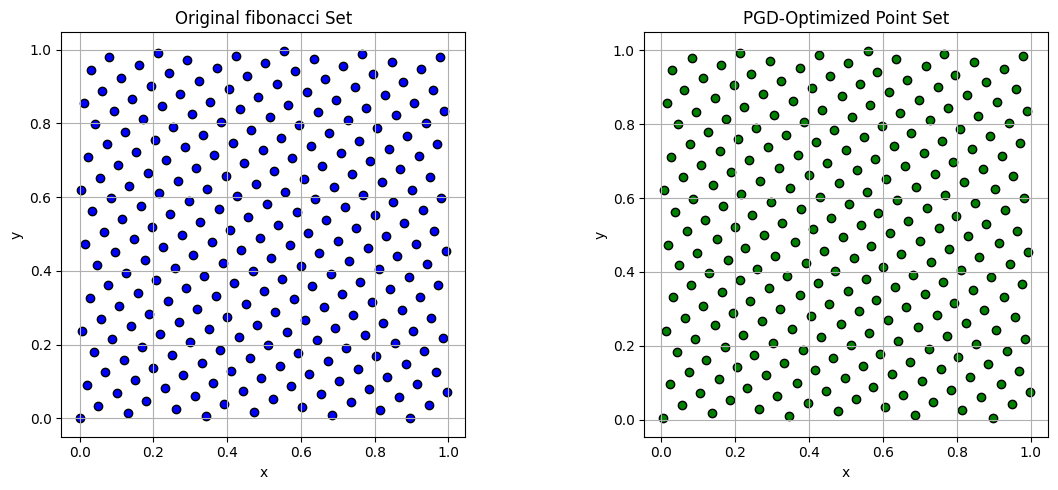

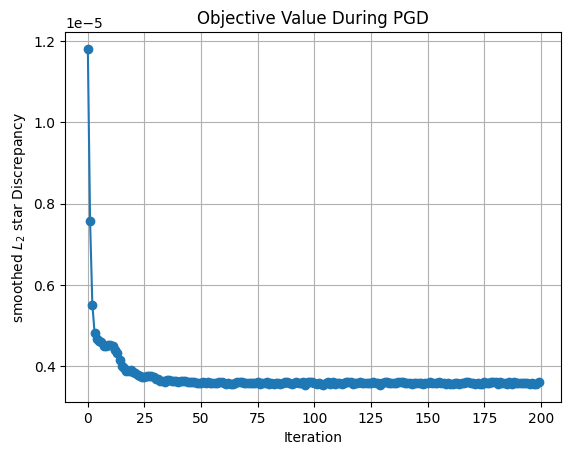

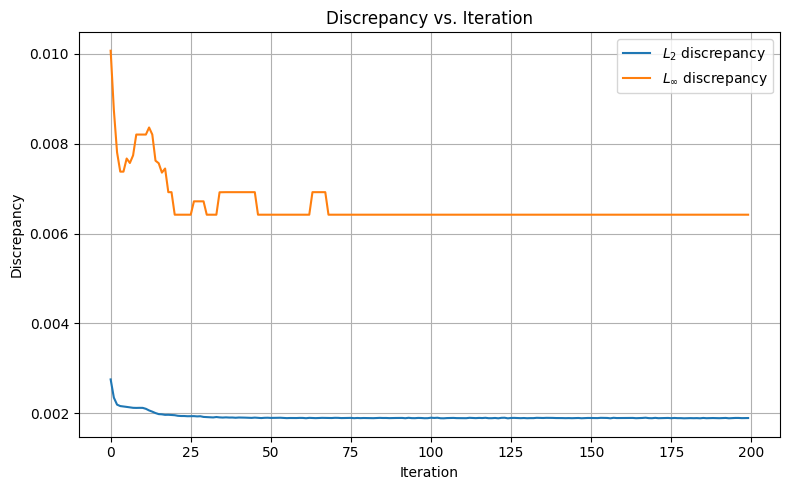

Initial L2 discrepancy: 0.00343827781118339
Final L2 discrepancy value: 0.0018934912813118434
Initial Linf discrepancy: 0.011995871122350676
Final Linf discrepancy value: 0.007035178418002885
Optimized Points:
 [[0.00383139 0.0038314 ]
 [0.00711906 0.62077534]
 [0.01239592 0.24079791]
 [0.01450542 0.85607094]
 [0.01823663 0.47417036]
 [0.02456917 0.09557693]
 [0.02695862 0.71190536]
 [0.03224462 0.33105001]
 [0.02964637 0.94600827]
 [0.03681204 0.56351918]
 [0.04216389 0.18395828]
 [0.04482831 0.79975849]
 [0.04873677 0.41819674]
 [0.05545939 0.04005336]
 [0.05803334 0.65690893]
 [0.06421033 0.27644324]
 [0.06098837 0.89179516]
 [0.0687039  0.50961047]
 [0.07483143 0.13041307]
 [0.07706414 0.74674046]
 [0.0816618  0.365486  ]
 [0.08350527 0.98053187]
 [0.08641358 0.59784371]
 [0.09136892 0.21779913]
 [0.09421033 0.83358318]
 [0.09776442 0.45173299]
 [0.10375956 0.07299569]
 [0.10687156 0.68977338]
 [0.111569   0.30890194]
 [0.11380969 0.92426491]
 [0.11695307 0.54187107]
 [0.1222029  0

In [3]:
#GENERIC FIBONACCI

# Use it for initial points
n = 260
P_init = fibonacci(n)

# ADAM optimizer setup
learning_rate = 0.001
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(P_init)

# Define loss function and gradient
loss_fn = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)

# Optimization loop
P = P_init
objective_history = []

L2_values = []
Linf_values = []

for i in range(200):
    loss_val, grads = loss_and_grad(P)
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)

    # Clamp to [0, 1]^2
    P = jnp.clip(P, 0.0, 1.0)
    objective_history.append(loss_val)
    
    L2_values.append(float(L2_discrepancy(np.array(P))))
    Linf_values.append(float(Linf_discrepancy(np.array(P))))


init_points = np.asarray(P_init).astype(np.float64)
optimized_points = np.asarray(P).astype(np.float64)
initial_L2_value = L2_discrepancy(init_points)
initial_Linf_value = discre(init_points.tolist())

# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original fibonacci Set")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].grid(True)
axs[0].set_aspect('equal')

axs[1].scatter(optimized_points[:, 0], optimized_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("PGD-Optimized Point Set")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].grid(True)
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()


# === Objective plot ===
plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(L2_values, label=r'$L_2$ discrepancy')
plt.plot(Linf_values, label=r'$L_\infty$ discrepancy')
plt.xlabel("Iteration")
plt.ylabel("Discrepancy")
plt.title("Discrepancy vs. Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Output ===
print("Initial L2 discrepancy:", initial_L2_value)
print("Final L2 discrepancy value:", L2_discrepancy(optimized_points))
print("Initial Linf discrepancy:", initial_Linf_value)
print("Final Linf discrepancy value:", discre(optimized_points.tolist()))
print("Optimized Points:\n", optimized_points)



In [4]:
print(len(P_init[0, :]))
print(len(P_init[:, 0]))

2
260


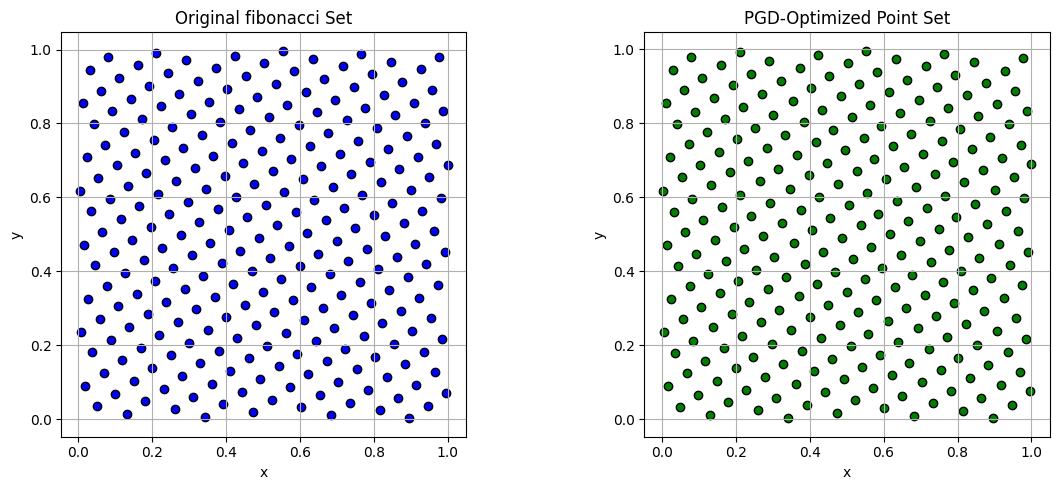

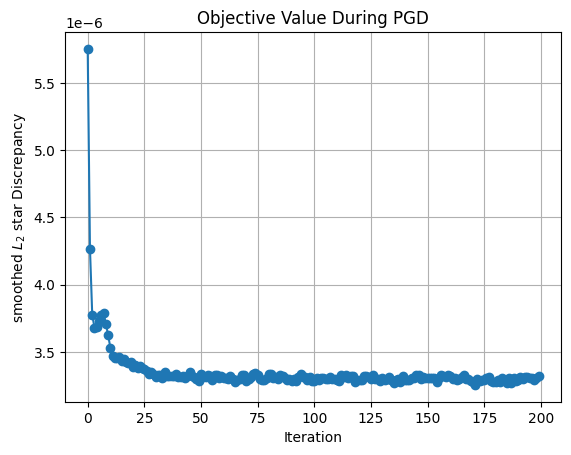

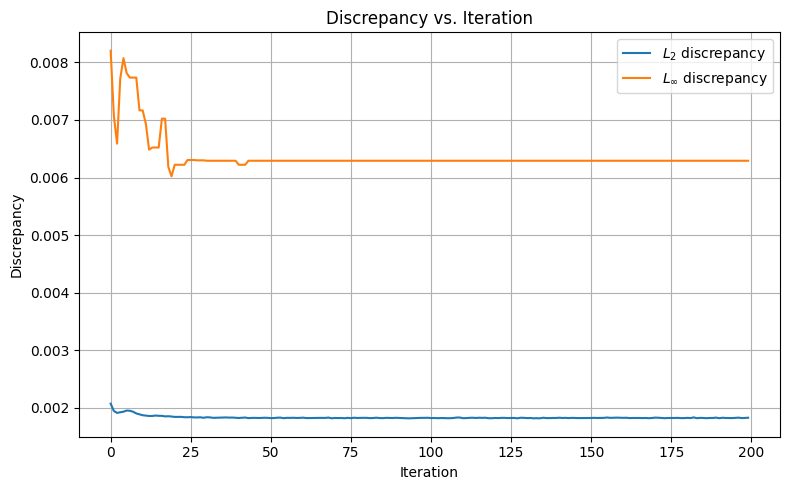

Initial L2 discrepancy: 0.0024024199824770032
Final L2 discrepancy value: 0.001819513168190177
Initial Linf discrepancy: 0.010214601655570754
Final Linf discrepancy value: 0.0071437777831323546
Optimized Points:
 [[0.00237828 0.6171965 ]
 [0.00623124 0.23482285]
 [0.01036932 0.85457879]
 [0.01306445 0.46971455]
 [0.01767247 0.08868477]
 [0.02250152 0.70946729]
 [0.02611478 0.32573098]
 [0.02966449 0.94482577]
 [0.03198258 0.55961716]
 [0.03588312 0.17775007]
 [0.04061498 0.79719198]
 [0.04348662 0.41345856]
 [0.04844089 0.03298282]
 [0.05351197 0.65353572]
 [0.05757634 0.27089915]
 [0.06105612 0.89002943]
 [0.06382252 0.50542235]
 [0.06848185 0.12402945]
 [0.07280017 0.7440635 ]
 [0.07636385 0.36050692]
 [0.07968202 0.97902107]
 [0.08183766 0.59415573]
 [0.08555087 0.21201333]
 [0.09016427 0.83112639]
 [0.09283005 0.44727299]
 [0.09731597 0.06642151]
 [0.10256211 0.686566  ]
 [0.10622073 0.30369136]
 [0.109965   0.92226601]
 [0.11234262 0.53791362]
 [0.11633274 0.15622872]
 [0.12121674

In [5]:
#FIBONACCI +1 SHIFT

# Use it for initial points
n = 260
P_init = fibonacci(n, shift = 1)

# ADAM optimizer setup
learning_rate = 0.001
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(P_init)

# Define loss function and gradient
loss_fn = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)

# Optimization loop
P = P_init
objective_history = []

L2_values = []
Linf_values = []

for i in range(200):
    loss_val, grads = loss_and_grad(P)
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)

    # Clamp to [0, 1]^2
    P = jnp.clip(P, 0.0, 1.0)
    objective_history.append(loss_val)
    
    L2_values.append(float(L2_discrepancy(np.array(P))))
    Linf_values.append(float(Linf_discrepancy(np.array(P))))


init_points = np.asarray(P_init).astype(np.float64)
optimized_points = np.asarray(P).astype(np.float64)
initial_L2_value = L2_discrepancy(init_points)
initial_Linf_value = discre(init_points.tolist())

# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original fibonacci Set")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].grid(True)
axs[0].set_aspect('equal')

axs[1].scatter(optimized_points[:, 0], optimized_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("PGD-Optimized Point Set")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].grid(True)
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()


# === Objective plot ===
plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(L2_values, label=r'$L_2$ discrepancy')
plt.plot(Linf_values, label=r'$L_\infty$ discrepancy')
plt.xlabel("Iteration")
plt.ylabel("Discrepancy")
plt.title("Discrepancy vs. Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Output ===
print("Initial L2 discrepancy:", initial_L2_value)
print("Final L2 discrepancy value:", L2_discrepancy(optimized_points))
print("Initial Linf discrepancy:", initial_Linf_value)
print("Final Linf discrepancy value:", discre(optimized_points.tolist()))
print("Optimized Points:\n", optimized_points)

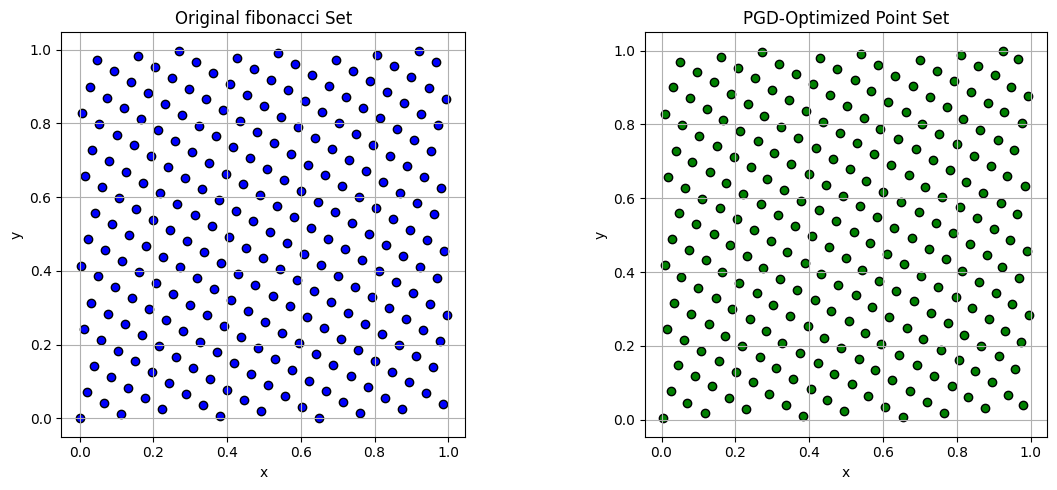

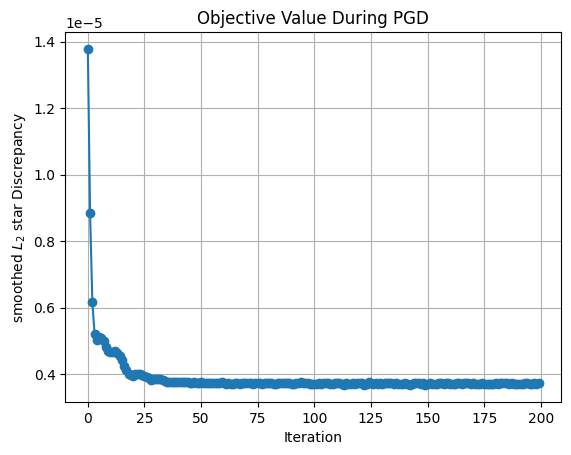

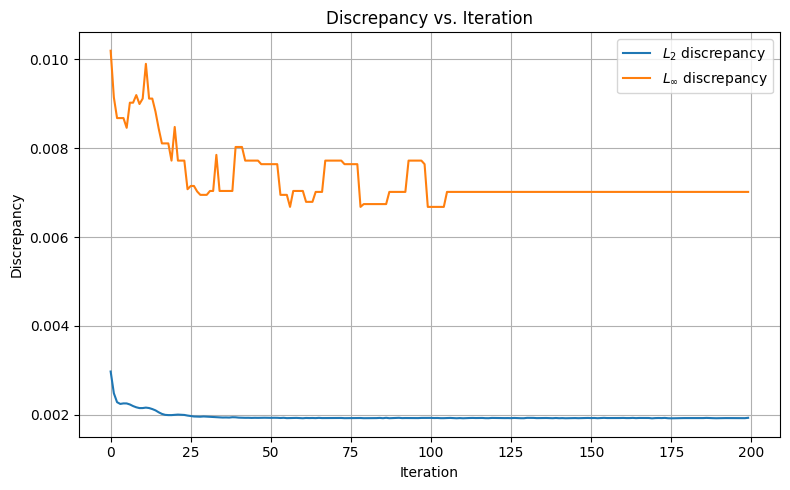

Initial L2 discrepancy: 0.003714312075537498
Final L2 discrepancy value: 0.0019273518100090294
Initial Linf discrepancy: 0.011919693307684665
Final Linf discrepancy value: 0.007960230216017938
Optimized Points:
 [[0.00383139 0.0038314 ]
 [0.00813644 0.41812992]
 [0.01051849 0.82828122]
 [0.01542981 0.2461689 ]
 [0.01856907 0.65772283]
 [0.02502801 0.07686394]
 [0.02843058 0.49047095]
 [0.0303569  0.90046763]
 [0.03501975 0.31757671]
 [0.03782179 0.72878402]
 [0.04359493 0.14702435]
 [0.04689651 0.56009287]
 [0.04880928 0.96999246]
 [0.05263428 0.38647673]
 [0.05558013 0.79738307]
 [0.06005251 0.21492417]
 [0.0638056  0.62725133]
 [0.06986593 0.04603745]
 [0.073855   0.45999333]
 [0.07607979 0.87066138]
 [0.08065063 0.28750178]
 [0.08377942 0.69941652]
 [0.08954813 0.11736304]
 [0.09311245 0.53077394]
 [0.09514395 0.94125068]
 [0.09910104 0.35753006]
 [0.10216748 0.7690143 ]
 [0.10690638 0.1863519 ]
 [0.11069658 0.59922498]
 [0.117272   0.01784042]
 [0.12110081 0.43216747]
 [0.12322051 

In [6]:
#ROOT 2 FIBONACCI

# Use it for initial points
n = 260
P_init = fibonacci(n, gen = jnp.sqrt(2))

# ADAM optimizer setup
learning_rate = 0.001
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(P_init)

# Define loss function and gradient
loss_fn = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)

# Optimization loop
P = P_init
objective_history = []

L2_values = []
Linf_values = []

for i in range(200):
    loss_val, grads = loss_and_grad(P)
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)

    # Clamp to [0, 1]^2
    P = jnp.clip(P, 0.0, 1.0)
    objective_history.append(loss_val)
    
    L2_values.append(float(L2_discrepancy(np.array(P))))
    Linf_values.append(float(Linf_discrepancy(np.array(P))))


init_points = np.asarray(P_init).astype(np.float64)
optimized_points = np.asarray(P).astype(np.float64)
initial_L2_value = L2_discrepancy(init_points)
initial_Linf_value = discre(init_points.tolist())

# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original fibonacci Set")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].grid(True)
axs[0].set_aspect('equal')

axs[1].scatter(optimized_points[:, 0], optimized_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("PGD-Optimized Point Set")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].grid(True)
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()


# === Objective plot ===
plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(L2_values, label=r'$L_2$ discrepancy')
plt.plot(Linf_values, label=r'$L_\infty$ discrepancy')
plt.xlabel("Iteration")
plt.ylabel("Discrepancy")
plt.title("Discrepancy vs. Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Output ===
print("Initial L2 discrepancy:", initial_L2_value)
print("Final L2 discrepancy value:", L2_discrepancy(optimized_points))
print("Initial Linf discrepancy:", initial_Linf_value)
print("Final Linf discrepancy value:", discre(optimized_points.tolist()))
print("Optimized Points:\n", optimized_points)

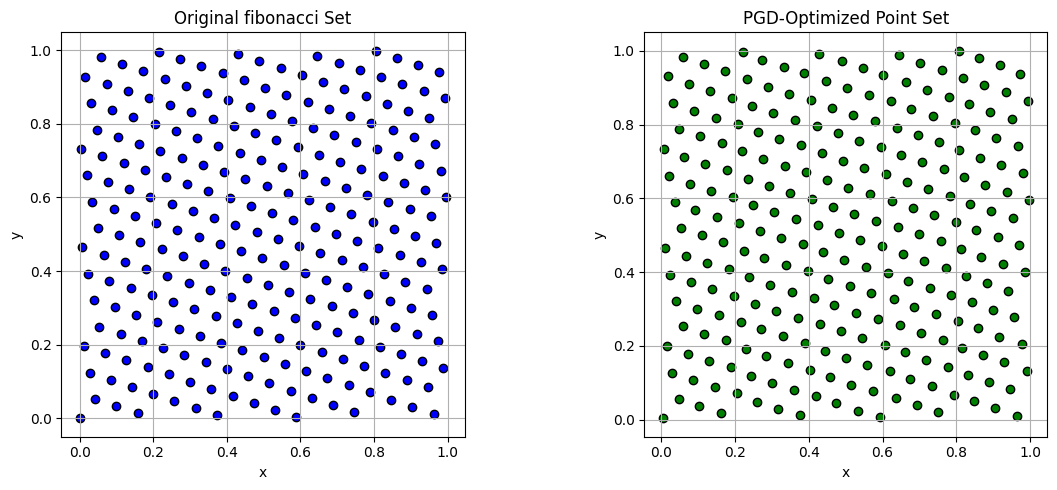

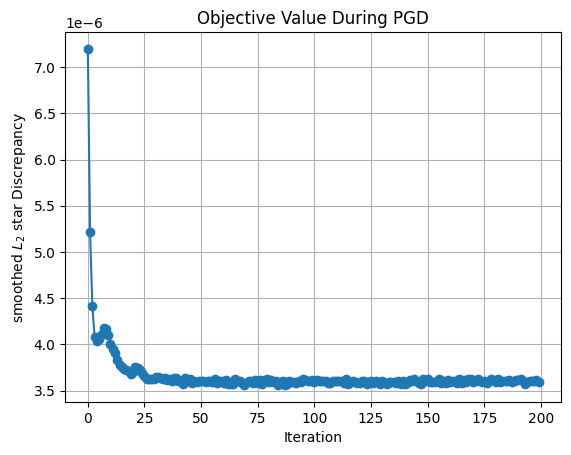

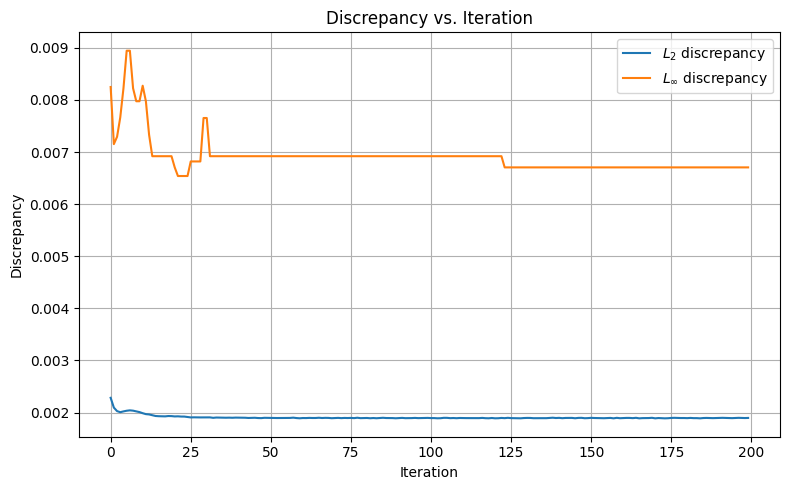

Initial L2 discrepancy: 0.0026815287355493643
Final L2 discrepancy value: 0.001895313377327271
Initial Linf discrepancy: 0.010334402571718804
Final Linf discrepancy value: 0.007633371394063726
Optimized Points:
 [[0.0038314  0.00383139]
 [0.00665073 0.73491389]
 [0.01047415 0.46658728]
 [0.01601018 0.20061944]
 [0.01792975 0.93061686]
 [0.02077821 0.66098356]
 [0.02478497 0.39321515]
 [0.03066455 0.12796132]
 [0.03307229 0.85839546]
 [0.03622599 0.58920693]
 [0.04067138 0.3220033 ]
 [0.04730487 0.05743791]
 [0.04945192 0.78834772]
 [0.05311304 0.51960492]
 [0.0583308  0.25297129]
 [0.06012119 0.98317456]
 [0.0626652  0.71309459]
 [0.0663511  0.44488704]
 [0.07164065 0.17896433]
 [0.07433432 0.90925145]
 [0.07714649 0.63978022]
 [0.08104606 0.37211478]
 [0.08673007 0.10688496]
 [0.08983954 0.83758634]
 [0.09296943 0.56855041]
 [0.0973613  0.3014411 ]
 [0.10388026 0.03688974]
 [0.10653249 0.76801139]
 [0.11024184 0.49942136]
 [0.1154881  0.2328826 ]
 [0.11737911 0.96325982]
 [0.12008566 

In [7]:
#ROOT 3 FIBONACCI

# Use it for initial points
n = 260
P_init = fibonacci(n, gen = jnp.sqrt(3))

# ADAM optimizer setup
learning_rate = 0.001
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(P_init)

# Define loss function and gradient
loss_fn = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)

# Optimization loop
P = P_init
objective_history = []

L2_values = []
Linf_values = []

for i in range(200):
    loss_val, grads = loss_and_grad(P)
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)

    # Clamp to [0, 1]^2
    P = jnp.clip(P, 0.0, 1.0)
    objective_history.append(loss_val)
    
    L2_values.append(float(L2_discrepancy(np.array(P))))
    Linf_values.append(float(Linf_discrepancy(np.array(P))))


init_points = np.asarray(P_init).astype(np.float64)
optimized_points = np.asarray(P).astype(np.float64)
initial_L2_value = L2_discrepancy(init_points)
initial_Linf_value = discre(init_points.tolist())

# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original fibonacci Set")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].grid(True)
axs[0].set_aspect('equal')

axs[1].scatter(optimized_points[:, 0], optimized_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("PGD-Optimized Point Set")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].grid(True)
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()


# === Objective plot ===
plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(L2_values, label=r'$L_2$ discrepancy')
plt.plot(Linf_values, label=r'$L_\infty$ discrepancy')
plt.xlabel("Iteration")
plt.ylabel("Discrepancy")
plt.title("Discrepancy vs. Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Output ===
print("Initial L2 discrepancy:", initial_L2_value)
print("Final L2 discrepancy value:", L2_discrepancy(optimized_points))
print("Initial Linf discrepancy:", initial_Linf_value)
print("Final Linf discrepancy value:", discre(optimized_points.tolist()))
print("Optimized Points:\n", optimized_points)

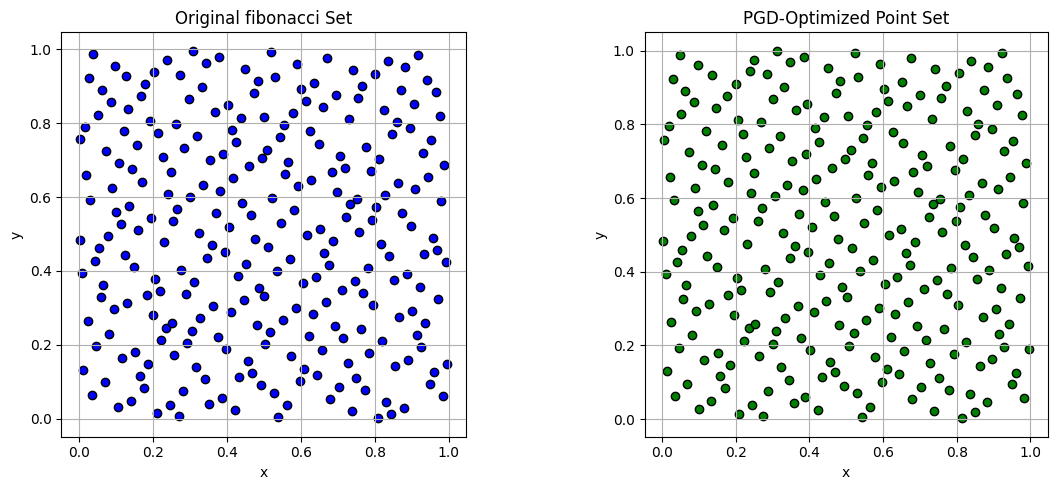

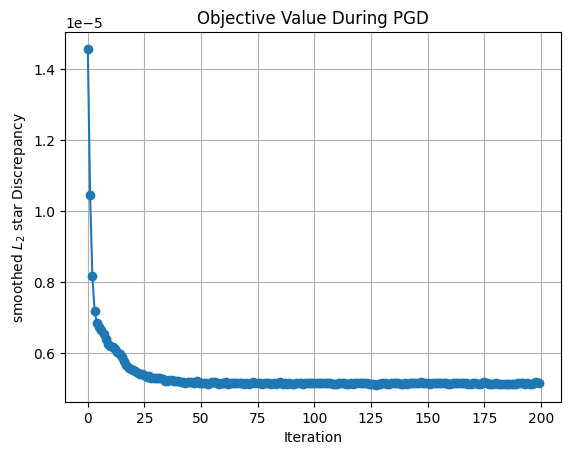

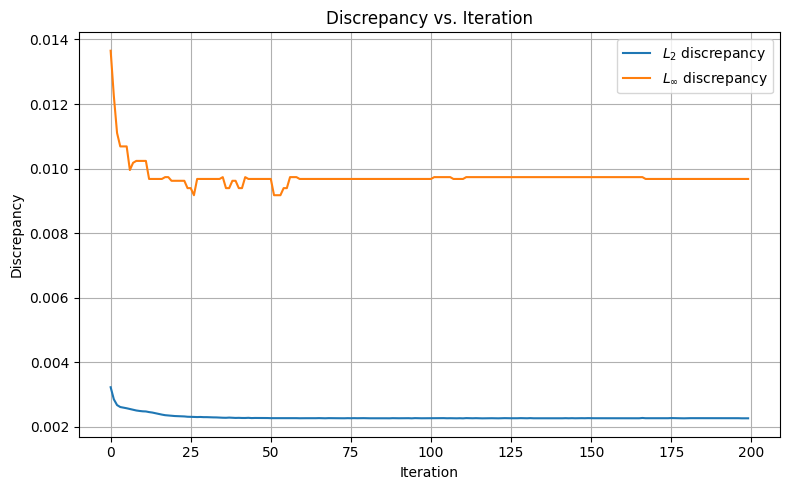

Initial L2 discrepancy: 0.0038162648746889313
Final L2 discrepancy value: 0.0022705257463565606
Initial Linf discrepancy: 0.016770536562203286
Final Linf discrepancy value: 0.009934309648131343
Optimized Points:
 [[0.50147051 0.33221489]
 [0.2505078  0.66739976]
 [0.75147074 0.11044204]
 [0.12352435 0.44404078]
 [0.62606484 0.77882153]
 [0.37832704 0.21899529]
 [0.87806785 0.55529732]
 [0.06228332 0.89093971]
 [0.56519717 0.03380039]
 [0.31598139 0.3732408 ]
 [0.81768233 0.70503509]
 [0.18581799 0.14802825]
 [0.68708843 0.48039892]
 [0.43952131 0.81912106]
 [0.94068682 0.2588926 ]
 [0.03202762 0.59415358]
 [0.53259832 0.92805457]
 [0.2868517  0.07582614]
 [0.78548425 0.41117766]
 [0.16363223 0.74313927]
 [0.65645635 0.18408631]
 [0.40695357 0.52161652]
 [0.90871114 0.85161555]
 [0.0925381  0.2946353 ]
 [0.59470206 0.63127875]
 [0.34628484 0.96830332]
 [0.84899795 0.01872101]
 [0.21527606 0.35064113]
 [0.71997958 0.68765301]
 [0.46982965 0.12752655]
 [0.96792573 0.46583119]
 [0.01927814

In [8]:
#HALTON

# Use it for initial points
n = 260
P_init = halton(n)

# ADAM optimizer setup
learning_rate = 0.001
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(P_init)

# Define loss function and gradient
loss_fn = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)

# Optimization loop
P = P_init
objective_history = []

L2_values = []
Linf_values = []

for i in range(200):
    loss_val, grads = loss_and_grad(P)
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)

    # Clamp to [0, 1]^2
    P = jnp.clip(P, 0.0, 1.0)
    objective_history.append(loss_val)
    
    L2_values.append(float(L2_discrepancy(np.array(P))))
    Linf_values.append(float(Linf_discrepancy(np.array(P))))


init_points = np.asarray(P_init).astype(np.float64)
optimized_points = np.asarray(P).astype(np.float64)
initial_L2_value = L2_discrepancy(init_points)
initial_Linf_value = discre(init_points.tolist())

# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original fibonacci Set")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].grid(True)
axs[0].set_aspect('equal')

axs[1].scatter(optimized_points[:, 0], optimized_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("PGD-Optimized Point Set")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].grid(True)
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()


# === Objective plot ===
plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(L2_values, label=r'$L_2$ discrepancy')
plt.plot(Linf_values, label=r'$L_\infty$ discrepancy')
plt.xlabel("Iteration")
plt.ylabel("Discrepancy")
plt.title("Discrepancy vs. Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Output ===
print("Initial L2 discrepancy:", initial_L2_value)
print("Final L2 discrepancy value:", L2_discrepancy(optimized_points))
print("Initial Linf discrepancy:", initial_Linf_value)
print("Final Linf discrepancy value:", discre(optimized_points.tolist()))
print("Optimized Points:\n", optimized_points)

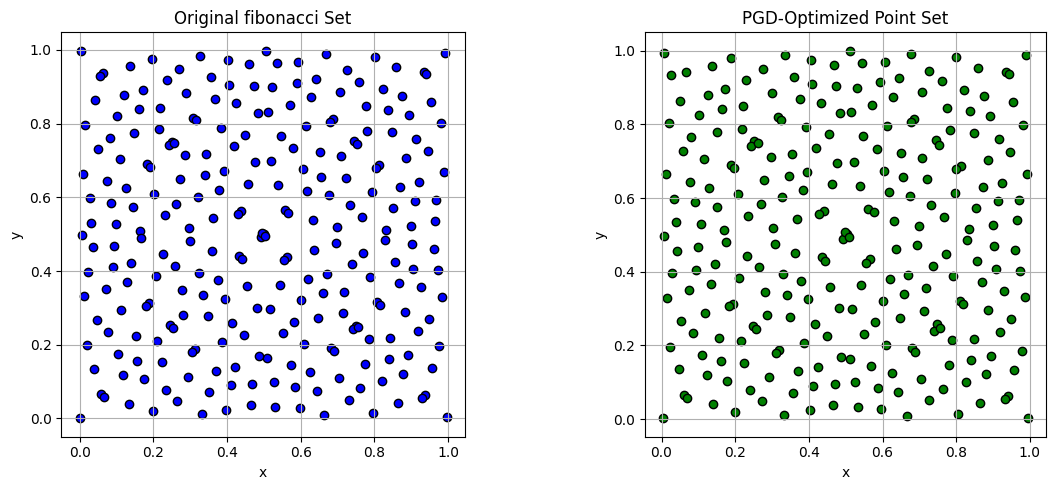

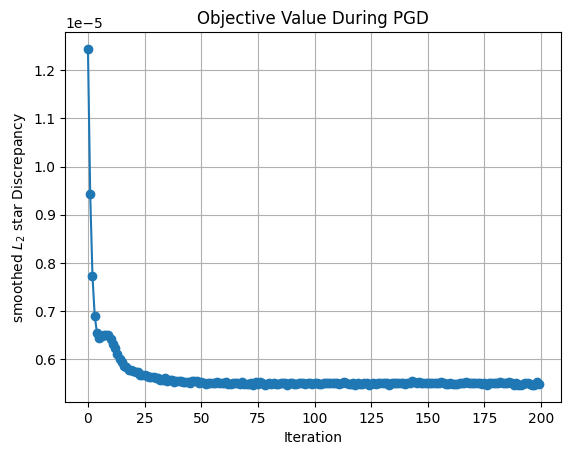

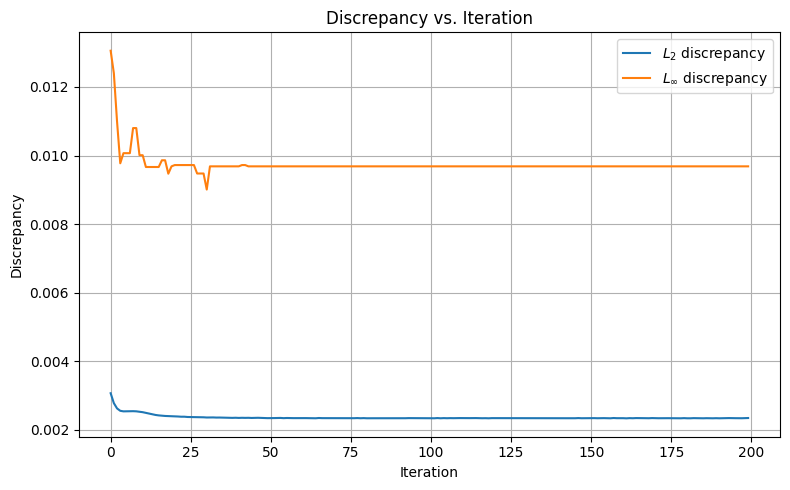

Initial L2 discrepancy: 0.0035253164527219005
Final L2 discrepancy value: 0.00234394630858643
Initial Linf discrepancy: 0.015464219651692257
Final Linf discrepancy value: 0.01015397192009837
Optimized Points:
 [[0.00383125 0.0038688 ]
 [0.50262773 0.50317156]
 [0.74903995 0.25675434]
 [0.25237474 0.75586706]
 [0.37932098 0.37463138]
 [0.87581706 0.87622541]
 [0.62631452 0.12551104]
 [0.13015622 0.62733716]
 [0.19287851 0.31355494]
 [0.68554378 0.81478494]
 [0.94085747 0.06175782]
 [0.43993697 0.56574172]
 [0.31829488 0.18833865]
 [0.81419849 0.68595487]
 [0.56513292 0.43546075]
 [0.06571462 0.94112062]
 [0.09939086 0.46656081]
 [0.60764486 0.97062182]
 [0.84754848 0.21710111]
 [0.35413435 0.71837717]
 [0.4719258  0.09447667]
 [0.9700579  0.59601617]
 [0.71763837 0.3554194 ]
 [0.22116067 0.84991223]
 [0.16144624 0.15705162]
 [0.65543139 0.65587789]
 [0.90895694 0.40810603]
 [0.40799379 0.90950239]
 [0.28720337 0.28258058]
 [0.78351849 0.78395814]
 [0.53417093 0.03266929]
 [0.03838862 0.

In [9]:
#SOBOL

# Use it for initial points
n = 260
P_init = sobol[0:n]

# ADAM optimizer setup
learning_rate = 0.001
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(P_init)

# Define loss function and gradient
loss_fn = lambda P: L2_smoothed(P)
loss_and_grad = jax.value_and_grad(loss_fn)

# Optimization loop
P = P_init
objective_history = []

L2_values = []
Linf_values = []

for i in range(200):
    loss_val, grads = loss_and_grad(P)
    updates, opt_state = optimizer.update(grads, opt_state)
    P = optax.apply_updates(P, updates)

    # Clamp to [0, 1]^2
    P = jnp.clip(P, 0.0, 1.0)
    objective_history.append(loss_val)
    
    L2_values.append(float(L2_discrepancy(np.array(P))))
    Linf_values.append(float(Linf_discrepancy(np.array(P))))


init_points = np.asarray(P_init).astype(np.float64)
optimized_points = np.asarray(P).astype(np.float64)
initial_L2_value = L2_discrepancy(init_points)
initial_Linf_value = discre(init_points.tolist())

# === Side-by-side: point sets ===
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(init_points[:, 0], init_points[:, 1], c='blue', edgecolor='black')
axs[0].set_title("Original fibonacci Set")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].grid(True)
axs[0].set_aspect('equal')

axs[1].scatter(optimized_points[:, 0], optimized_points[:, 1], c='green', edgecolor='black')
axs[1].set_title("PGD-Optimized Point Set")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].grid(True)
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()


# === Objective plot ===
plt.figure()
plt.plot(objective_history, marker='o')
plt.title("Objective Value During PGD")
plt.xlabel("Iteration")
plt.ylabel("smoothed $L_2$ star Discrepancy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(L2_values, label=r'$L_2$ discrepancy')
plt.plot(Linf_values, label=r'$L_\infty$ discrepancy')
plt.xlabel("Iteration")
plt.ylabel("Discrepancy")
plt.title("Discrepancy vs. Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Output ===
print("Initial L2 discrepancy:", initial_L2_value)
print("Final L2 discrepancy value:", L2_discrepancy(optimized_points))
print("Initial Linf discrepancy:", initial_Linf_value)
print("Final Linf discrepancy value:", discre(optimized_points.tolist()))
print("Optimized Points:\n", optimized_points)